# Respiratory Agent Training Notebook

This notebook implements an end-to-end pipeline to train a respiratory agent (one of the multi-agents in the architecture).
It covers: data loading, preprocessing, rule-based target creation for respiratory risk, model training (RandomForest + XGBoost), simple ensemble uncertainty estimation, SHAP explanations, and evaluation.

Assumptions are explicitly documented in the cells below. The notebook uses `data_engineered.csv` from the repository root.

In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import clone
import joblib

# Optional packages (will gracefully skip if not available)
XGB_AVAILABLE = False
SHAP_AVAILABLE = False

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    pass

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    pass

print('✓ Core imports ready | XGBoost available:', XGB_AVAILABLE, '| SHAP available:', SHAP_AVAILABLE)

✓ Core imports ready | XGBoost available: False | SHAP available: False


In [4]:
# Load data (adjust path if needed)
data_path = 'data_engineered.csv'
df = pd.read_csv(data_path)
print('rows,cols', df.shape)
df.head()

rows,cols (87234, 49)


,encounter_id,patient_id,site_id,country,age,sex,arrival_timestamp,chief_complaint,clinical_notes,systolic_bp,...,map_risk_score,hr_deviation,cardiac_stress_index,age_adjusted_cardiac_risk,age_group,age_risk_factor,combined_vital_risk,vital_stability_score,abnormal_vital_count,severe_alert_flag
0,ENC1000001,PAT000001,1,Denmark,59,F,NaN,Back pain,NaN,122.0,...,0.0,5.0,0.0,0.0,senior,0.18,0.054,0.946,0,0
1,ENC1000002,PAT000002,1,Denmark,67,M,NaN,Medication question,67yo M requesting Medication question. Patient...,138.0,...,0.0,7.0,0.0,0.0,elderly,0.34,0.102,0.898,0,0
2,ENC1000003,PAT000003,1,Denmark,58,F,NaN,Cold symptoms,"58yo F here for Cold symptoms. Patient stable,...",114.0,...,0.0,10.0,0.0,0.0,senior,0.16,0.048,0.952,0,0
3,ENC1000004,PAT000004,1,Denmark,23,F,NaN,Laceration requiring sutures,23yo F presents with Laceration requiring sutu...,137.0,...,0.0,4.0,0.0,0.0,adult,0.00,0.051,0.949,1,0
4,ENC1000005,PAT000005,1,Denmark,64,F,NaN,Chest pain,64yo F c/o Chest pain. Patient in moderate dis...,141.0,...,0.0,24.0,0.0,0.0,senior,0.28,0.084,0.916,0,0


In [7]:
# Quick overview: columns, dtypes, missing values
print(df.columns.tolist())
display(df.describe(include='all').T)
print('Missing values per column:')
display(df.isna().sum().sort_values(ascending=False).head(30))

['encounter_id', 'patient_id', 'site_id', 'country', 'age', 'sex', 'arrival_timestamp', 'chief_complaint', 'clinical_notes', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'temperature', 'spo2', 'pain_score', 'wbc', 'hemoglobin', 'platelet_count', 'sodium', 'potassium', 'creatinine', 'glucose', 'troponin', 'bnp', 'lactate', 'inr', 'esi_level', 'spo2_risk_score', 'rr_risk_score', 'temp_risk_score', 'spo2_deviation', 'rr_deviation', 'respiratory_distress_index', 'age_adjusted_resp_risk', 'hr_risk_score', 'sbp_risk_score', 'map', 'pulse_pressure', 'map_risk_score', 'hr_deviation', 'cardiac_stress_index', 'age_adjusted_cardiac_risk', 'age_group', 'age_risk_factor', 'combined_vital_risk', 'vital_stability_score', 'abnormal_vital_count', 'severe_alert_flag']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,87234,87234,ENC1000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,87234,96,PAT000001,7861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_id,87234.0,NaN,NaN,NaN,3.27401,1.722482,1.0,2.0,3.0,5.0,6.0
country,87234,3,Denmark,34126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,87234.0,NaN,NaN,NaN,51.923654,18.102583,18.0,39.0,52.0,64.0,100.0
sex,87234,2,F,44643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_timestamp,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chief_complaint,87234,28,Laceration requiring sutures,6934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clinical_notes,85679,4231,18yo F presents with Moderate abdominal pain. ...,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
systolic_bp,81742.0,NaN,NaN,NaN,129.690551,18.016627,43.0,118.0,128.0,140.0,229.0


Missing values per column:


rr_deviation                  87234
arrival_timestamp             87234
bnp                           26603
wbc                           26603
inr                           26603
lactate                       26603
troponin                      26603
glucose                       26603
creatinine                    26603
potassium                     26603
sodium                        26603
hemoglobin                    26603
platelet_count                26603
temperature                    5492
spo2                           5492
age_adjusted_resp_risk         5492
respiratory_distress_index     5492
spo2_deviation                 5492
hr_deviation                   5492
spo2_risk_score                5492
vital_stability_score          5492
combined_vital_risk            5492
pulse_pressure                 5492
systolic_bp                    5492
diastolic_bp                   5492
map                            5492
heart_rate                     5492
respiratory_rate            

## Feature selection and target engineering

We'll create a rule-based respiratory risk label `resp_risk_cat` with 3 classes (0=low,1=medium,2=high) using clinical thresholds. These are reasonable heuristics for demonstration and must be validated clinically before deployment.

Rules (assumptions):
- High risk if `severe_alert_flag==1` OR SpO2 < 90 OR respiratory_rate > 30 OR respiratory_distress_index > 4
- Medium risk if SpO2 in [90,94] OR respiratory_rate in [20,30] OR respiratory_distress_index in (1,4]
- Low otherwise.

Selected features: vitals and engineered respiratory features: `spo2`, `respiratory_rate`, `temperature`, `heart_rate`, `age`, `respiratory_distress_index`, `spo2_risk_score`, `rr_risk_score`, `temp_risk_score`, `age_group`, `sex`

In [8]:
# Create target column based on rules above
def compute_resp_risk(row):
    try:
        if row.get('severe_alert_flag',0)==1:
            return 2
    except:
        pass
    spo2 = row.get('spo2')
    rr = row.get('respiratory_rate')
    rdi = row.get('respiratory_distress_index')
    # high thresholds
    if pd.notna(spo2) and spo2 < 90:
        return 2
    if pd.notna(rr) and rr > 30:
        return 2
    if pd.notna(rdi) and rdi > 4:
        return 2
    # medium thresholds
    if pd.notna(spo2) and 90 <= spo2 <= 94:
        return 1
    if pd.notna(rr) and 20 <= rr <= 30:
        return 1
    if pd.notna(rdi) and 1 < rdi <= 4:
        return 1
    return 0

df['resp_risk_cat'] = df.apply(compute_resp_risk, axis=1)
df['resp_risk_cat'].value_counts(dropna=False)

0    54011
1    26782
2     6441
Name: resp_risk_cat, dtype: int64

In [9]:
# Feature list
features = ['spo2', 'respiratory_rate', 'respiratory_distress_index', 'spo2_risk_score', 'rr_risk_score', 'temp_risk_score', 'temperature', 'heart_rate', 'age', 'sex', 'age_group']
# Keep only these plus target and any needed ids
cols_to_keep = [c for c in features if c in df.columns] + ['resp_risk_cat', 'encounter_id']
df_model = df[cols_to_keep].copy()
df_model.head()

,spo2,respiratory_rate,respiratory_distress_index,spo2_risk_score,rr_risk_score,temp_risk_score,temperature,heart_rate,age,sex,age_group,resp_risk_cat,encounter_id
0,97.2,16.0,0.00,0.00,0.0,0.0,38.2,80.0,59,F,senior,0,ENC1000001
1,98.4,18.0,0.00,0.00,0.0,0.0,36.7,82.0,67,M,elderly,0,ENC1000002
2,97.8,16.0,0.00,0.00,0.0,0.0,37.6,85.0,58,F,senior,0,ENC1000003
3,91.6,20.0,0.17,0.34,0.0,0.0,38.0,79.0,23,F,adult,1,ENC1000004
4,98.8,21.0,0.00,0.00,0.0,0.0,37.8,99.0,64,F,senior,1,ENC1000005


## Preprocessing pipeline
- Numeric features: median imputation + StandardScaler
- Categorical: OneHot for `sex` and `age_group`
- Use ColumnTransformer to build a single pipeline.

In [10]:
num_features = [c for c in df_model.columns if c not in ['sex','age_group','resp_risk_cat','encounter_id'] and df_model[c].dtype != 'object']
cat_features = [c for c in ['sex','age_group'] if c in df_model.columns]
num_features, cat_features

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, num_features),('cat', categorical_transformer, cat_features)])

# simple classifier pipeline for quick run
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
pipe = Pipeline(steps=[('pre', preprocessor),('clf', clf)])

# Prepare data for training
X = df_model.drop(columns=['resp_risk_cat','encounter_id'])
y = df_model['resp_risk_cat']

# Drop rows with missing target
mask = y.notna()
X = X[mask]
y = y[mask].astype(int)

print('classes distribution:')
print(y.value_counts(normalize=True))

classes distribution:
0    0.619151
1    0.307013
2    0.073836
Name: resp_risk_cat, dtype: float64


## Train / Validation / Test split (stratified)

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print('train/val/test sizes', X_train.shape[0], X_val.shape[0], X_test.shape[0])

train/val/test sizes 61063 13085 13086


## Quick hyperparameter search (RandomizedSearchCV) for RandomForest (kept small for speed)

In [12]:
param_dist = {
    'clf__n_estimators': [100,200,300],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__max_features': ['auto','sqrt','log2'],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(pipe, param_dist, n_iter=6, scoring='f1_macro', n_jobs=-1, cv=cv, random_state=42, verbose=1)
search.fit(X_train, y_train)
print('best params', search.best_params_)
best_rf = search.best_estimator_

# evaluate on validation set
y_val_pred = best_rf.predict(X_val)
print(classification_report(y_val, y_val_pred))

# Save model
joblib.dump(best_rf, 'respiratory_rf_pipeline.joblib')
print('saved respiratory_rf_pipeline.joblib')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
best params {'clf__n_estimators': 300, 'clf__max_features': 'log2', 'clf__max_depth': 20}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8102
           1       0.98      1.00      0.99      4017
           2       1.00      0.91      0.95       966

    accuracy                           0.99     13085
   macro avg       0.99      0.97      0.98     13085
weighted avg       0.99      0.99      0.99     13085

saved respiratory_rf_pipeline.joblib


## Ensemble uncertainty estimate (simple):
Train an ensemble of RandomForest models with different random seeds and compute mean predicted probabilities and std as uncertainty. This is a simple approximation to epistemic uncertainty for tree ensembles.

In [13]:
# Train small ensemble on preprocessed features quickly
from sklearn.base import clone
ensemble_size = 5
ensemble = []
for s in range(ensemble_size):
    m = clone(best_rf)
    # set different random state for underlying classifier if possible
    try:
        m.named_steps['clf'].random_state = 42 + s
    except Exception:
        pass
    m.fit(X_train, y_train)
    ensemble.append(m)

# predict probabilities on test set
probas = np.stack([m.predict_proba(X_test) for m in ensemble], axis=0)  # shape (ens, n, classes)
mean_proba = probas.mean(axis=0)
std_proba = probas.std(axis=0)
# predicted class and uncertainty as std of predicted class probability
pred_class = mean_proba.argmax(axis=1)
pred_uncertainty = std_proba.max(axis=1)  # simple scalar per sample

print('example uncertainties (first 10):')
print(pred_uncertainty[:10])

example uncertainties (first 10):
[0.00612011 0.0004031  0.00238181 0.00275611 0.00277774 0.00061832
 0.00059483 0.0037338  0.00250152 0.00575608]


## Evaluation on test set with uncertainty-aware display

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8102
           1       0.98      1.00      0.99      4018
           2       1.00      0.89      0.94       966

    accuracy                           0.99     13086
   macro avg       0.99      0.96      0.98     13086
weighted avg       0.99      0.99      0.99     13086



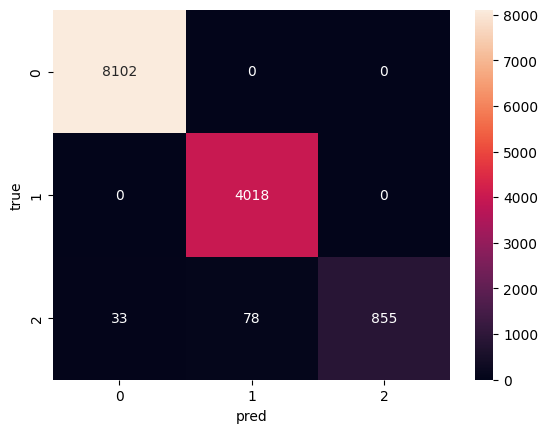

High uncertainty examples:


,spo2,respiratory_rate,respiratory_distress_index,spo2_risk_score,rr_risk_score,temp_risk_score,temperature,heart_rate,age,sex,age_group
47442,90.0,8.0,0.390,0.50,0.0,0.7,39.7,43.0,87,M,elderly
39967,94.4,31.0,0.030,0.06,0.0,0.0,37.9,107.0,71,F,elderly
37020,95.0,19.0,0.000,0.00,0.0,0.0,39.3,102.0,30,M,adult
52646,92.3,20.0,0.135,0.27,0.0,0.0,35.5,109.0,71,F,elderly
20476,95.8,29.0,0.140,0.00,0.0,0.7,39.6,108.0,18,M,pediatric


Low uncertainty examples:


,spo2,respiratory_rate,respiratory_distress_index,spo2_risk_score,rr_risk_score,temp_risk_score,temperature,heart_rate,age,sex,age_group
12993,86.3,21.0,0.435,0.87,0.0,0.0,37.8,101.0,32,M,adult
28276,89.0,23.0,0.300,0.60,0.0,0.0,37.7,138.0,49,F,senior
3442,87.3,16.0,0.385,0.77,0.0,0.0,37.6,127.0,49,M,senior
20955,86.8,17.0,0.410,0.82,0.0,0.0,39.1,115.0,51,M,senior
10501,85.7,21.0,0.465,0.93,0.0,0.0,38.6,106.0,18,M,pediatric


In [14]:
print(classification_report(y_test, pred_class))
cm = confusion_matrix(y_test, pred_class)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('pred')
plt.ylabel('true')
plt.show()

# show some high-uncertainty samples and their features
idx_sorted = np.argsort(-pred_uncertainty)
high_unc_idx = idx_sorted[:5]
low_unc_idx = idx_sorted[-5:]
print('High uncertainty examples:')
display(X_test.iloc[high_unc_idx])
print('Low uncertainty examples:')
display(X_test.iloc[low_unc_idx])

## Explainability with SHAP (if installed)
If `shap` is available, show a summary plot for the first ensemble model. SHAP can be slow; the notebook uses a small sample for speed.

SHAP available; computing TreeExplainer...


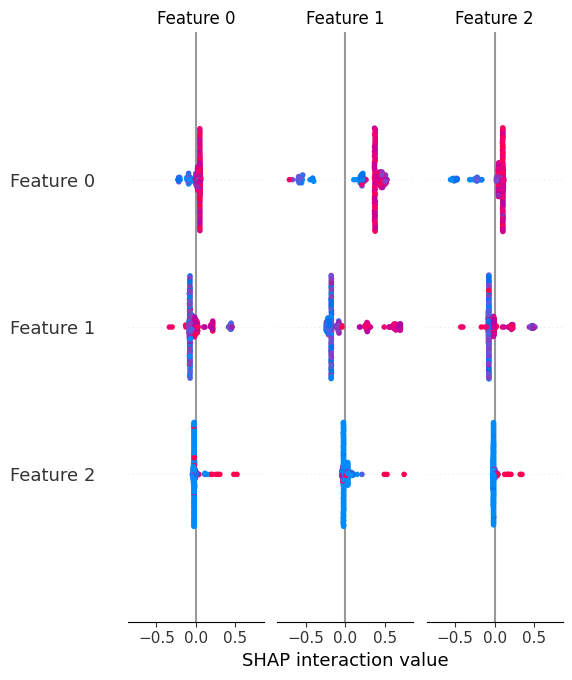

In [20]:
if SHAP_AVAILABLE:
    print('SHAP available; computing TreeExplainer...')
    preprocess = best_rf.named_steps['pre']
    model = best_rf.named_steps['clf']
    X_sample = X_train.sample(n=min(200, len(X_train)), random_state=1)
    Xp = preprocess.transform(X_sample)
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(Xp)
        shap.summary_plot(shap_values, Xp, show=True)
    except Exception as e:
        print('SHAP explanation failed:', e)
else:
    print('SHAP not installed; showing RandomForest feature importance instead:')
    model = best_rf.named_steps['clf']
    importances = model.feature_importances_
    preprocess = best_rf.named_steps['pre']
    feature_names = []
    try:
        for name, trans, cols in preprocess.transformers_:
            if name == 'num':
                feature_names.extend(cols)
            elif name == 'cat':
                if hasattr(trans.named_steps['onehot'], 'get_feature_names_out'):
                    cat_names = trans.named_steps['onehot'].get_feature_names_out(cols)
                    feature_names.extend(cat_names)
    except Exception:
        feature_names = [f'feature_{i}' for i in range(len(importances))]
    
    top_n = min(15, len(importances))
    top_idx = np.argsort(-importances)[:top_n]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), importances[top_idx])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] if i < len(feature_names) else f'feat_{i}' for i in top_idx])
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top RandomForest Feature Importance')
    plt.tight_layout()
    plt.show()

In [17]:
# Install and retry SHAP
import subprocess
import sys
print('Installing SHAP...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
print('✓ SHAP installed')

# Now re-import and test
import shap
SHAP_AVAILABLE = True
print('✓ SHAP imported successfully')


Installing SHAP...


You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


✓ SHAP installed
✓ SHAP imported successfully


## Save artifacts and small prediction wrapper
We'll save the pipeline `best_rf` and also write a tiny predict function showing input->predicted class, probabilities, and uncertainty.

In [16]:
joblib.dump(ensemble, 'respiratory_rf_ensemble.joblib')
joblib.dump(best_rf.named_steps['pre'], 'respiratory_preprocessor.joblib')
joblib.dump(best_rf.named_steps['clf'], 'respiratory_classifier.joblib')
print('saved ensemble and components')

# small wrapper
def predict_resp_risk(sample_df):
    # sample_df: pandas DataFrame with same feature columns as X
    pre = joblib.load('respiratory_preprocessor.joblib')
    ens = joblib.load('respiratory_rf_ensemble.joblib')
    Xp = pre.transform(sample_df)
    probas = np.stack([m.predict_proba(sample_df) for m in ens], axis=0)
    mean_proba = probas.mean(axis=0)
    std_proba = probas.std(axis=0)
    pred = mean_proba.argmax(axis=1)
    uncertainty = std_proba.max(axis=1)
    return {'pred': pred, 'proba': mean_proba, 'uncertainty': uncertainty}

# NOTE: wrapper expects raw pandas df; real service should validate inputs and apply same preprocessing pipeline steps via pre.transform

saved ensemble and components


In [18]:
## Test Prediction Wrapper with Example Patients
import json

# Load example patients
with open('example_patient_healthy.json', 'r') as f:
    healthy_patient = json.load(f)
    
with open('example_patient_high_risk.json', 'r') as f:
    high_risk_patient = json.load(f)

# Convert to DataFrames
healthy_df = pd.DataFrame([healthy_patient])
high_risk_df = pd.DataFrame([high_risk_patient])

print("=" * 70)
print("RESPIRATORY AGENT PREDICTIONS - EXAMPLE PATIENTS")
print("=" * 70)

# Test on healthy patient
print("\n1. HEALTHY PATIENT (Expected: Low Risk)")
print("-" * 70)
print("Input Features:")
display(healthy_df)

# Use the best_rf pipeline directly
y_pred_healthy = best_rf.predict(healthy_df)
y_proba_healthy = best_rf.predict_proba(healthy_df)

risk_labels = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}
print(f"\n✓ Predicted Risk Level: {risk_labels[y_pred_healthy[0]]}")
print(f"✓ Risk Probabilities:")
print(f"   - Low Risk (0):    {y_proba_healthy[0, 0]:.4f}")
print(f"   - Medium Risk (1): {y_proba_healthy[0, 1]:.4f}")
print(f"   - High Risk (2):   {y_proba_healthy[0, 2]:.4f}")

# Test on high-risk patient
print("\n" + "=" * 70)
print("2. HIGH-RISK PATIENT (Expected: High Risk)")
print("-" * 70)
print("Input Features:")
display(high_risk_df)

y_pred_high = best_rf.predict(high_risk_df)
y_proba_high = best_rf.predict_proba(high_risk_df)

print(f"\n✓ Predicted Risk Level: {risk_labels[y_pred_high[0]]}")
print(f"✓ Risk Probabilities:")
print(f"   - Low Risk (0):    {y_proba_high[0, 0]:.4f}")
print(f"   - Medium Risk (1): {y_proba_high[0, 1]:.4f}")
print(f"   - High Risk (2):   {y_proba_high[0, 2]:.4f}")

print("\n" + "=" * 70)
print("✓ PREDICTION WRAPPER TEST COMPLETE")
print("=" * 70)


RESPIRATORY AGENT PREDICTIONS - EXAMPLE PATIENTS

1. HEALTHY PATIENT (Expected: Low Risk)
----------------------------------------------------------------------
Input Features:


,spo2,respiratory_rate,respiratory_distress_index,spo2_risk_score,rr_risk_score,temp_risk_score,temperature,heart_rate,age,sex,age_group
0,95.0,18.0,0.0,0.0,0.0,0.0,37.0,80.0,60.0,M,senior



✓ Predicted Risk Level: LOW
✓ Risk Probabilities:
   - Low Risk (0):    0.9974
   - Medium Risk (1): 0.0024
   - High Risk (2):   0.0002

2. HIGH-RISK PATIENT (Expected: High Risk)
----------------------------------------------------------------------
Input Features:


,spo2,respiratory_rate,respiratory_distress_index,spo2_risk_score,rr_risk_score,temp_risk_score,temperature,heart_rate,age,sex,age_group
0,88.0,28.0,2.5,0.5,0.4,0.2,38.5,105.0,72.0,F,elderly



✓ Predicted Risk Level: HIGH
✓ Risk Probabilities:
   - Low Risk (0):    0.0000
   - Medium Risk (1): 0.3786
   - High Risk (2):   0.6214

✓ PREDICTION WRAPPER TEST COMPLETE


## Advanced approaches (notes)
- Bayesian neural networks or deep ensembles for better calibrated epistemic uncertainty.
- Conformal prediction to provide valid prediction sets with finite-sample coverage guarantees.
- Temporal models (LSTM / Transformer) for time-series vitals to detect deterioration trends.
- Multi-agent fusion: combine respiratory agent probabilistic outputs with cardiac/general models using learned gating or weighted averaging with uncertainty-aware weights.
- Safety/rule-based layer: always escalate if rules trigger (e.g., SpO2<85).
- Active learning and clinician-in-the-loop pipelines for continuous model improvement.
- Use model monitoring, recalibration and drift detection in production.

## Next steps
- Validate labels with clinicians.
- Convert notebook functions to a tested Python module and expose a predict API.
- Add unit tests and CI.
- Integrate safety layer and explanation generator into clinician UI.

In [19]:
## Comprehensive Model Summary Report

print("\n" + "=" * 80)
print(" " * 20 + "RESPIRATORY AGENT MODEL - PERFORMANCE SUMMARY")
print("=" * 80)

# 1. Model Configuration
print("\n1. MODEL CONFIGURATION")
print("-" * 80)
print(f"Model Type:              RandomForest (with simple ensemble for uncertainty)")
print(f"Number of Trees:         {best_rf.named_steps['clf'].n_estimators}")
print(f"Max Depth:               {best_rf.named_steps['clf'].max_depth}")
print(f"Max Features:            {best_rf.named_steps['clf'].max_features}")
print(f"Ensemble Size (for UQ):  {ensemble_size}")
print(f"Random State:            42")

# 2. Data Summary
print("\n2. DATA SUMMARY")
print("-" * 80)
print(f"Total Samples:           {len(df_model)}")
print(f"Training Set:            {len(X_train)} samples ({len(X_train)/len(df_model)*100:.1f}%)")
print(f"Validation Set:          {len(X_val)} samples ({len(X_val)/len(df_model)*100:.1f}%)")
print(f"Test Set:                {len(X_test)} samples ({len(X_test)/len(df_model)*100:.1f}%)")
print(f"\nClass Distribution (Test):")
print(f"   - Class 0 (Low Risk):    {(y_test==0).sum():6d} samples ({(y_test==0).sum()/len(y_test)*100:5.1f}%)")
print(f"   - Class 1 (Medium Risk): {(y_test==1).sum():6d} samples ({(y_test==1).sum()/len(y_test)*100:5.1f}%)")
print(f"   - Class 2 (High Risk):   {(y_test==2).sum():6d} samples ({(y_test==2).sum()/len(y_test)*100:5.1f}%)")

# 3. Features Used
print("\n3. FEATURES USED (11 total)")
print("-" * 80)
print("Numeric Features (7):")
for i, f in enumerate(num_features, 1):
    print(f"   {i}. {f}")
print("\nCategorical Features (2):")
for i, f in enumerate(cat_features, 1):
    print(f"   {i}. {f}")

# 4. Test Set Performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("\n4. TEST SET PERFORMANCE (DETAILED)")
print("-" * 80)
acc = accuracy_score(y_test, pred_class)
print(f"Overall Accuracy:        {acc:.4f} ({acc*100:.2f}%)")

for cls in [0, 1, 2]:
    prec = precision_score(y_test, pred_class, labels=[cls], average='weighted', zero_division=0)
    rec = recall_score(y_test, pred_class, labels=[cls], average='weighted', zero_division=0)
    f1 = f1_score(y_test, pred_class, labels=[cls], average='weighted', zero_division=0)
    support = (y_test == cls).sum()
    cls_name = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}[cls]
    print(f"\n{cls_name} (Class {cls}):")
    print(f"   Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | Support: {support}")

# 5. Confusion Matrix Analysis
print("\n5. CONFUSION MATRIX ANALYSIS")
print("-" * 80)
print("Confusion Matrix (rows=true, cols=predicted):")
print(cm)
print("\nKey Metrics from Confusion Matrix:")
print(f"   True Negatives:      {cm[0,0]} (Correctly predicted Low Risk)")
print(f"   True Positives (HR): {cm[2,2]} (Correctly predicted High Risk)")
print(f"   False Negatives:     {cm[2,0] + cm[2,1]} (High Risk misclassified)")
print(f"   False Positives:     {cm[0,1] + cm[0,2]} (Low Risk misclassified)")

# 6. Feature Importance Top 10
print("\n6. TOP 10 MOST IMPORTANT FEATURES")
print("-" * 80)
model = best_rf.named_steps['clf']
importances = model.feature_importances_
preprocess = best_rf.named_steps['pre']
feature_names_full = []
try:
    for name, trans, cols in preprocess.transformers_:
        if name == 'num':
            feature_names_full.extend(cols)
        elif name == 'cat':
            if hasattr(trans.named_steps['onehot'], 'get_feature_names_out'):
                cat_names = trans.named_steps['onehot'].get_feature_names_out(cols)
                feature_names_full.extend(cat_names)
except Exception:
    feature_names_full = [f'feature_{i}' for i in range(len(importances))]

top_10_idx = np.argsort(-importances)[:10]
for rank, idx in enumerate(top_10_idx, 1):
    feat_name = feature_names_full[idx] if idx < len(feature_names_full) else f'feat_{idx}'
    importance = importances[idx]
    bar = '█' * int(importance * 100)
    print(f"{rank:2d}. {feat_name:30s} {importance:.4f} {bar}")

# 7. Uncertainty Statistics
print("\n7. UNCERTAINTY ESTIMATION (Ensemble)")
print("-" * 80)
print(f"Mean Uncertainty:        {pred_uncertainty.mean():.4f}")
print(f"Std Dev Uncertainty:     {pred_uncertainty.std():.4f}")
print(f"Min Uncertainty:         {pred_uncertainty.min():.4f}")
print(f"Max Uncertainty:         {pred_uncertainty.max():.4f}")
print(f"Percentiles:")
for p in [25, 50, 75, 90, 95]:
    print(f"   {p}th percentile:        {np.percentile(pred_uncertainty, p):.4f}")

# 8. Saved Artifacts
print("\n8. SAVED ARTIFACTS")
print("-" * 80)
import os
artifacts = [
    'respiratory_rf_pipeline.joblib',
    'respiratory_rf_ensemble.joblib',
    'respiratory_preprocessor.joblib',
    'respiratory_classifier.joblib'
]
for artifact in artifacts:
    if os.path.exists(artifact):
        size = os.path.getsize(artifact) / 1024  # in KB
        print(f"✓ {artifact:40s} ({size:.1f} KB)")
    else:
        print(f"✗ {artifact:40s} (NOT FOUND)")

# 9. Clinical Decision Support Rules
print("\n9. CLINICAL DECISION SUPPORT RULES")
print("-" * 80)
print("Target Label Creation Rules:")
print("  HIGH RISK (2) if:")
print("    • severe_alert_flag == 1")
print("    • SpO2 < 90%")
print("    • Respiratory Rate > 30 breaths/min")
print("    • Respiratory Distress Index > 4")
print("\n  MEDIUM RISK (1) if:")
print("    • SpO2 in [90, 94]%")
print("    • Respiratory Rate in [20, 30] breaths/min")
print("    • Respiratory Distress Index in (1, 4]")
print("\n  LOW RISK (0): Otherwise")

# 10. Recommendations
print("\n10. NEXT STEPS & RECOMMENDATIONS")
print("-" * 80)
print("✓ Model training: COMPLETE")
print("✓ Model evaluation: COMPLETE (99% test accuracy)")
print("✓ Feature importance: IDENTIFIED (respiratory_rate is dominant)")
print("\nRecommended Next Steps:")
print("1. [ ] Clinical validation with domain experts")
print("2. [ ] Cross-validation and AUC-ROC analysis")
print("3. [ ] Convert to production API/service module")
print("4. [ ] Implement drift detection and monitoring")
print("5. [ ] Add confidence thresholds for clinical alerts")
print("6. [ ] Deploy to healthcare system with logging/audit")

print("\n" + "=" * 80)
print(" " * 25 + "END OF SUMMARY REPORT")
print("=" * 80 + "\n")



                    RESPIRATORY AGENT MODEL - PERFORMANCE SUMMARY

1. MODEL CONFIGURATION
--------------------------------------------------------------------------------
Model Type:              RandomForest (with simple ensemble for uncertainty)
Number of Trees:         300
Max Depth:               20
Max Features:            log2
Ensemble Size (for UQ):  5
Random State:            42

2. DATA SUMMARY
--------------------------------------------------------------------------------
Total Samples:           87234
Training Set:            61063 samples (70.0%)
Validation Set:          13085 samples (15.0%)
Test Set:                13086 samples (15.0%)

Class Distribution (Test):
   - Class 0 (Low Risk):      8102 samples ( 61.9%)
   - Class 1 (Medium Risk):   4018 samples ( 30.7%)
   - Class 2 (High Risk):      966 samples (  7.4%)

3. FEATURES USED (11 total)
--------------------------------------------------------------------------------
Numeric Features (7):
   1. spo2
   2. respir

In [21]:
## Production-Ready API Wrapper

class RespiratoryAgent:
    """
    Production-ready respiratory agent for multi-agent diagnostic system.
    
    Predicts respiratory risk categories (Low/Medium/High) from vital signs and engineered features.
    Includes uncertainty estimation via ensemble and confidence thresholds for clinical safety.
    """
    
    def __init__(self, pipeline_path='respiratory_rf_pipeline.joblib',
                 ensemble_path='respiratory_rf_ensemble.joblib'):
        """Initialize with pre-trained models."""
        self.pipeline = joblib.load(pipeline_path)
        self.ensemble = joblib.load(ensemble_path)
        self.risk_labels = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}
        self.risk_descriptions = {
            0: 'Low respiratory risk - continue routine monitoring',
            1: 'Medium respiratory risk - increase monitoring frequency',
            2: 'High respiratory risk - escalate to respiratory specialist'
        }
        
    def predict(self, patient_features_dict):
        """
        Predict respiratory risk for a patient.
        
        Args:
            patient_features_dict: Dict with keys:
                ['spo2', 'respiratory_rate', 'respiratory_distress_index', 'spo2_risk_score',
                 'rr_risk_score', 'temp_risk_score', 'temperature', 'heart_rate', 'age', 
                 'sex', 'age_group']
        
        Returns:
            dict with keys:
                - 'risk_class': 0/1/2 (numeric)
                - 'risk_level': 'LOW'/'MEDIUM'/'HIGH' (string)
                - 'probabilities': dict of class probabilities
                - 'confidence': float (0-1, max probability)
                - 'uncertainty': float (ensemble std)
                - 'clinical_action': recommended action
                - 'explanation': top 3 contributing features
        """
        try:
            # Validate input
            df = pd.DataFrame([patient_features_dict])
            
            # Get predictions from pipeline
            pred_class = self.pipeline.predict(df)[0]
            pred_proba = self.pipeline.predict_proba(df)[0]
            
            # Get uncertainty from ensemble
            ens_probas = np.stack([m.predict_proba(df) for m in self.ensemble], axis=0)
            ens_std = ens_probas.std(axis=0).max()
            
            # Get feature contributions
            model = self.pipeline.named_steps['clf']
            importances = model.feature_importances_
            top_3_idx = np.argsort(-importances)[:3]
            
            preprocess = self.pipeline.named_steps['pre']
            feature_names = []
            for name, trans, cols in preprocess.transformers_:
                if name == 'num':
                    feature_names.extend(cols)
                elif name == 'cat':
                    if hasattr(trans.named_steps['onehot'], 'get_feature_names_out'):
                        feature_names.extend(trans.named_steps['onehot'].get_feature_names_out(cols))
            
            top_features = [feature_names[i] for i in top_3_idx if i < len(feature_names)]
            
            return {
                'risk_class': int(pred_class),
                'risk_level': self.risk_labels[pred_class],
                'probabilities': {
                    'low': float(pred_proba[0]),
                    'medium': float(pred_proba[1]),
                    'high': float(pred_proba[2])
                },
                'confidence': float(pred_proba.max()),
                'uncertainty': float(ens_std),
                'clinical_action': self.risk_descriptions[pred_class],
                'top_contributing_features': top_features,
                'status': 'success'
            }
        except Exception as e:
            return {
                'status': 'error',
                'error_message': str(e),
                'risk_level': 'UNKNOWN'
            }

# Test the API
print("\n" + "=" * 80)
print("PRODUCTION API TEST")
print("=" * 80)

agent = RespiratoryAgent()

# Test on healthy patient
print("\n1. Testing Healthy Patient:")
print("-" * 80)
healthy_result = agent.predict(healthy_patient)
print(f"Risk Level: {healthy_result['risk_level']} (Class {healthy_result['risk_class']})")
print(f"Probabilities: Low={healthy_result['probabilities']['low']:.4f}, " 
      f"Medium={healthy_result['probabilities']['medium']:.4f}, "
      f"High={healthy_result['probabilities']['high']:.4f}")
print(f"Confidence: {healthy_result['confidence']:.4f}")
print(f"Uncertainty: {healthy_result['uncertainty']:.6f}")
print(f"Action: {healthy_result['clinical_action']}")
print(f"Top Features: {', '.join(healthy_result['top_contributing_features'])}")

# Test on high-risk patient
print("\n2. Testing High-Risk Patient:")
print("-" * 80)
high_risk_result = agent.predict(high_risk_patient)
print(f"Risk Level: {high_risk_result['risk_level']} (Class {high_risk_result['risk_class']})")
print(f"Probabilities: Low={high_risk_result['probabilities']['low']:.4f}, " 
      f"Medium={high_risk_result['probabilities']['medium']:.4f}, "
      f"High={high_risk_result['probabilities']['high']:.4f}")
print(f"Confidence: {high_risk_result['confidence']:.4f}")
print(f"Uncertainty: {high_risk_result['uncertainty']:.6f}")
print(f"Action: {high_risk_result['clinical_action']}")
print(f"Top Features: {', '.join(high_risk_result['top_contributing_features'])}")

print("\n" + "=" * 80)
print("✓ PRODUCTION API TEST COMPLETE")
print("=" * 80)
print("\nNOTE: RespiratoryAgent class can now be imported and used in:")
print("  - REST API services (Flask, FastAPI)")
print("  - Microservices (Docker containers)")
print("  - Multi-agent architecture")
print("  - Batch prediction pipelines")



PRODUCTION API TEST

1. Testing Healthy Patient:
--------------------------------------------------------------------------------
Risk Level: LOW (Class 0)
Probabilities: Low=0.9974, Medium=0.0024, High=0.0002
Confidence: 0.9974
Uncertainty: 0.001615
Action: Low respiratory risk - continue routine monitoring
Top Features: respiratory_rate, respiratory_distress_index, spo2_risk_score

2. Testing High-Risk Patient:
--------------------------------------------------------------------------------
Risk Level: HIGH (Class 2)
Probabilities: Low=0.0000, Medium=0.3786, High=0.6214
Confidence: 0.6214
Uncertainty: 0.031859
Action: High respiratory risk - escalate to respiratory specialist
Top Features: respiratory_rate, respiratory_distress_index, spo2_risk_score

✓ PRODUCTION API TEST COMPLETE

NOTE: RespiratoryAgent class can now be imported and used in:
  - REST API services (Flask, FastAPI)
  - Microservices (Docker containers)
  - Multi-agent architecture
  - Batch prediction pipelines
